Install Libraries

In [92]:
! pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Rumeth\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Import Libraries

In [93]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

Load Dataset

In [94]:
df = pd.read_csv((r"C:\Users\Rumeth\Downloads\fertilizer_recommendation.csv"))
df.head()  # displays the first 5 rows of the dataset

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


Features and Target Seperation

In [95]:
X = df.drop(columns=["Recommended_Fertilizer", "Season", "Region"])  # features for prediction
Y = df["Recommended_Fertilizer"]  # target variable for prediction

print("Features shape:", X.shape)  # prints the shape of the features
print("Target shape:", Y.shape)  # prints the shape of the target variable

Features shape: (10000, 17)
Target shape: (10000,)


Check Unique Classes

In [96]:
print("Number of unique fertilizers:", Y.nunique())  # prints the number of unique fertilizers in the target variable

print("\nUnique fertilizers and their counts:")  # prints the unique fertilizers and their counts
print(Y.value_counts())  # prints the counts of each unique fertilizer in the target variable

Number of unique fertilizers: 7

Unique fertilizers and their counts:
Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64


Dataset Split into Training and Testing

In [97]:
X_train, X_test, Y_train, Y_test = train_test_split(  
    X,      # Input features
    Y,      # Target variable
    test_size=0.2,  # Allocates 20% of the data for testing and 80% for training
    random_state=42,    # Ensures reproducibility of the split
    stratify=Y  # Maintains the class distribution in both sets
    )  

print("Training data:", X_train.shape) # Display the dimensions of the training dataset
print("Testing data:", X_test.shape) # Display the dimensions of the testing dataset

Training data: (8000, 17)
Testing data: (2000, 17)


Verify Class Distribution in Testing and Training Sets

In [98]:
print("Training target distribution:")
print(Y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(Y_test.value_counts(normalize=True).round(3))

Training target distribution:
Recommended_Fertilizer
Urea             0.310
DAP              0.292
MOP              0.141
Compost          0.100
Zinc Sulphate    0.075
NPK              0.064
SSP              0.018
Name: proportion, dtype: float64

Testing target distribution:
Recommended_Fertilizer
Urea             0.310
DAP              0.292
MOP              0.141
Compost          0.100
Zinc Sulphate    0.075
NPK              0.064
SSP              0.018
Name: proportion, dtype: float64


Create Preprocessing Pipeline

In [99]:
# Seperating numerical and categorical features 
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["str"]
).columns.tolist()

Numeric Pipeline

In [100]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median") # handles missing values by replacing them with the median of the column
        ),
        (
            "scaler",
            StandardScaler() # standardizes features by removing the mean and scaling to unit variance
        )
    ]
)

Categorical Pipeline

In [101]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",  # fills missing values with a constant value
                fill_value="Unknown"  # fills missing values with the string "Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore" # ignores any unknown categories encountered during transformation
            )
        )
    ]
)

Combined Preprocessor

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features  # applies the numeric_transformer to the numerical features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features  # applies the categorical_transformer to the categorical features
        )
    ]
) 

Preprocessing the Training and Testing Data

In [103]:
X_train_preprocessed = preprocessor.fit_transform(X_train)  # fits the preprocessor to the training data and transforms it
X_test_preprocessed = preprocessor.transform(X_test)  # transforms the testing data using the fitted preprocessor

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_preprocessed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_preprocessed.shape)

Original training shape: (8000, 17)
Processed training shape: (8000, 38)

Original testing shape: (2000, 17)
Processed testing shape: (2000, 38)


Encode Target Labels

In [104]:
label_encoder = LabelEncoder()

Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

label_mapping = {   # creates a mapping of the encoded labels to their original string labels
    label: index
    for index, label in enumerate(label_encoder.classes_)
}

print(label_mapping)

{'Compost': 0, 'DAP': 1, 'MOP': 2, 'NPK': 3, 'SSP': 4, 'Urea': 5, 'Zinc Sulphate': 6}


In [105]:
print("X_train_processed:", X_train_preprocessed.shape)
print("X_test_processed:", X_test_preprocessed.shape)

print("Y_train_encoded:", Y_train_encoded.shape)
print("Y_test_encoded:", Y_test_encoded.shape)

X_train_processed: (8000, 38)
X_test_processed: (2000, 38)
Y_train_encoded: (8000,)
Y_test_encoded: (2000,)


In [106]:
feature_names = preprocessor.get_feature_names_out()  # retrieves the names of the features after preprocessing

print ("Number of preprocessed features:", len(feature_names))  # prints the number of preprocessed features
print("\nFirst 20 Features: ")
print(feature_names[:20])  # prints the first 20 feature names after preprocessing

Number of preprocessed features: 38

First 20 Features: 
['num__Soil_pH' 'num__Soil_Moisture' 'num__Organic_Carbon'
 'num__Electrical_Conductivity' 'num__Nitrogen_Level'
 'num__Phosphorus_Level' 'num__Potassium_Level' 'num__Temperature'
 'num__Humidity' 'num__Rainfall' 'num__Fertilizer_Used_Last_Season'
 'num__Yield_Last_Season' 'cat__Soil_Type_Clay' 'cat__Soil_Type_Loamy'
 'cat__Soil_Type_Sandy' 'cat__Soil_Type_Silt' 'cat__Crop_Type_Cotton'
 'cat__Crop_Type_Maize' 'cat__Crop_Type_Potato' 'cat__Crop_Type_Rice']


Convert Preprocessed Data to DataFrames

In [107]:
X_train_processed_df = pd.DataFrame(
    X_train_preprocessed,  # creates a DataFrame from the preprocessed training data
    columns=feature_names,  # assigns the feature names as column headers for the DataFrame
    index=X_train.index  # assigns the original index of the training data to the DataFrame
)

X_test_processed_df = pd.DataFrame(
    X_test_preprocessed,    # creates a DataFrame from the preprocessed test data
    columns=feature_names,  # assigns the feature names as column headers for the DataFrame
    index=X_test.index  # assigns the original index of the test data to the DataFrame
)

X_train_processed_df.head()

,num__Soil_pH,num__Soil_Moisture,num__Organic_Carbon,num__Electrical_Conductivity,num__Nitrogen_Level,num__Phosphorus_Level,num__Potassium_Level,num__Temperature,num__Humidity,num__Rainfall,...,cat__Irrigation_Type_Drip,cat__Irrigation_Type_Rainfed,cat__Irrigation_Type_Sprinkler,cat__Previous_Crop_Cotton,cat__Previous_Crop_Maize,cat__Previous_Crop_Potato,cat__Previous_Crop_Rice,cat__Previous_Crop_Sugarcane,cat__Previous_Crop_Tomato,cat__Previous_Crop_Wheat
9497,-0.184123,1.594732,1.041974,0.457637,-0.813498,0.125873,-0.470426,1.111746,-1.262523,-1.285614,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1229,-0.374158,1.086289,-1.505230,-1.556179,0.254867,-1.549997,0.630400,-0.423554,-0.527011,-0.929895,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4168,-0.788779,-1.528065,-0.593599,1.144703,-0.888036,-0.475721,-1.413992,-0.257858,-1.641476,-0.808610,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8971,0.161395,0.084663,-1.263916,-0.158354,-1.434641,-0.475721,-1.130922,-0.810566,-0.157819,0.504572,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6074,-0.685124,-0.922512,0.183968,0.279947,-0.142664,-0.819490,-1.099470,-1.729429,1.260382,0.617745,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Feature Engineering

In [108]:
def create_features(df):

    # Create a copy to avoid modifying the original dataset
    df = df.copy()

    # Total NPK
    df["Total_NPK"] = (df["Nitrogen_Level"] + df["Phosphorus_Level"] + df["Potassium_Level"])

    # NPK Ratios
    df["N_to_P_Ratio"] = (df["Nitrogen_Level"] / (df["Phosphorus_Level"] + 1))

    df["N_to_K_Ratio"] = (df["Nitrogen_Level"] / (df["Potassium_Level"] + 1))

    df["P_to_K_Ratio"] = (df["Phosphorus_Level"] / (df["Potassium_Level"] + 1))

    # NPK Balance
    npk_columns = ["Nitrogen_Level", "Phosphorus_Level", "Potassium_Level"]

    df["NPK_Std"] = df[npk_columns].std(axis=1)

    # Soil pH Category
    def classify_soil_ph(ph):

        if ph < 5.5:
            return "Acidic"

        elif ph <= 7.5:
            return "Neutral"

        else:
            return "Alkaline"

    df["Soil_pH_Category"] = df["Soil_pH"].apply(classify_soil_ph)

    # Temperature-Humidity Interaction
    df["Temp_Humidity_Interaction"] = (df["Temperature"] * df["Humidity"])

    # Rainfall-Soil Moisture Interaction
    df["Rainfall_Soil_Moisture_Interaction"] = (df["Rainfall"] * df["Soil_Moisture"])

    return df


# Apply Feature Engineering
X_train_fe = create_features(X_train)
X_test_fe = create_features(X_test)

Identify New Feature Types

In [109]:
numerical_features_fe = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(include=["str"]).columns.tolist()

Create New Preprocessor

In [110]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features_fe
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features_fe
        )
    ]
)

In [111]:
# Process training data
X_train_fe_processed = preprocessor_fe.fit_transform(X_train_fe) 

# Process testing data
X_test_fe_processed = preprocessor_fe.transform(X_test_fe)

print("Feature Engineering Completed")

print("Original features:",X_train.shape[1])

print("Features after engineering:",X_train_fe.shape[1])

print("Processed features:",X_train_fe_processed.shape[1])

print("\nNew Features:")

new_features = [
    "Total_NPK",
    "N_to_P_Ratio",
    "N_to_K_Ratio",
    "P_to_K_Ratio",
    "NPK_Std",
    "Soil_pH_Category",
    "Temp_Humidity_Interaction",
    "Rainfall_Soil_Moisture_Interaction"
]

for feature in new_features:
    print("-", feature)

Feature Engineering Completed
Original features: 17
Features after engineering: 25
Processed features: 48

New Features:
- Total_NPK
- N_to_P_Ratio
- N_to_K_Ratio
- P_to_K_Ratio
- NPK_Std
- Soil_pH_Category
- Temp_Humidity_Interaction
- Rainfall_Soil_Moisture_Interaction


Model Evaluation

In [112]:
# Dictionary to store evaluation results for each model
results = {}

def evaluate_model(model, X_train, Y_train, X_test, Y_test, model_name):

    # Train model
    model.fit(X_train, Y_train)

    # Make predictions
    Y_pred = model.predict(X_test)

    # Calculate the accuracy
    accuracy = accuracy_score(Y_test, Y_pred)

    # Calculate macro-average precision across all classes
    precision = precision_score(
        Y_test,    
        Y_pred,
        average="macro",  
        zero_division=0
    )

    # Calculate macro-average recall across all classes
    recall = recall_score(
        Y_test,
        Y_pred,
        average="macro",
        zero_division=0
    )

    # Calculate macro-average F1 score across all classes
    f1 = f1_score(
        Y_test,
        Y_pred,
        average="macro",
        zero_division=0
    )

    # Store results
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 Score (Macro)": f1
    }

    # Print results
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")

    return model, Y_pred

Logistic Regresssion Model

In [113]:
logistic_model = LogisticRegression(max_iter = 2000, random_state = 42)

logistic_model, logistic_predictions = evaluate_model(
    logistic_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Logistic Regression"
)

Logistic Regression
Accuracy: 0.8090
Precision (Macro): 0.6829
Recall (Macro): 0.6716
F1 Score (Macro): 0.6745


Decision Tree Model

In [114]:
decision_tree_model = DecisionTreeClassifier(
    random_state = 42
)

decision_tree_model, decision_tree_predictions = evaluate_model(
    decision_tree_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Decision Tree"
)

Decision Tree
Accuracy: 0.8775
Precision (Macro): 0.7405
Recall (Macro): 0.7442
F1 Score (Macro): 0.7420


Random Forest Model

In [115]:
random_forest_model = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight="balanced",
    n_jobs = -1
)

random_forest_model, random_forest_predictions = evaluate_model(
    random_forest_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Random Forest"
)

Random Forest
Accuracy: 0.8720
Precision (Macro): 0.7302
Recall (Macro): 0.7601
F1 Score (Macro): 0.7386


Summary of Results

In [116]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Logistic Regression,0.8090,0.682947,0.671559,0.674546
Decision Tree,0.8775,0.740510,0.744189,0.742039
Random Forest,0.8720,0.730194,0.760096,0.738605


Sort by F1 Score

In [117]:
results_df = results_df.sort_values(
    by="F1 Score (Macro)",
    ascending=False
)

results_df

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Decision Tree,0.8775,0.740510,0.744189,0.742039
Random Forest,0.8720,0.730194,0.760096,0.738605
Logistic Regression,0.8090,0.682947,0.671559,0.674546


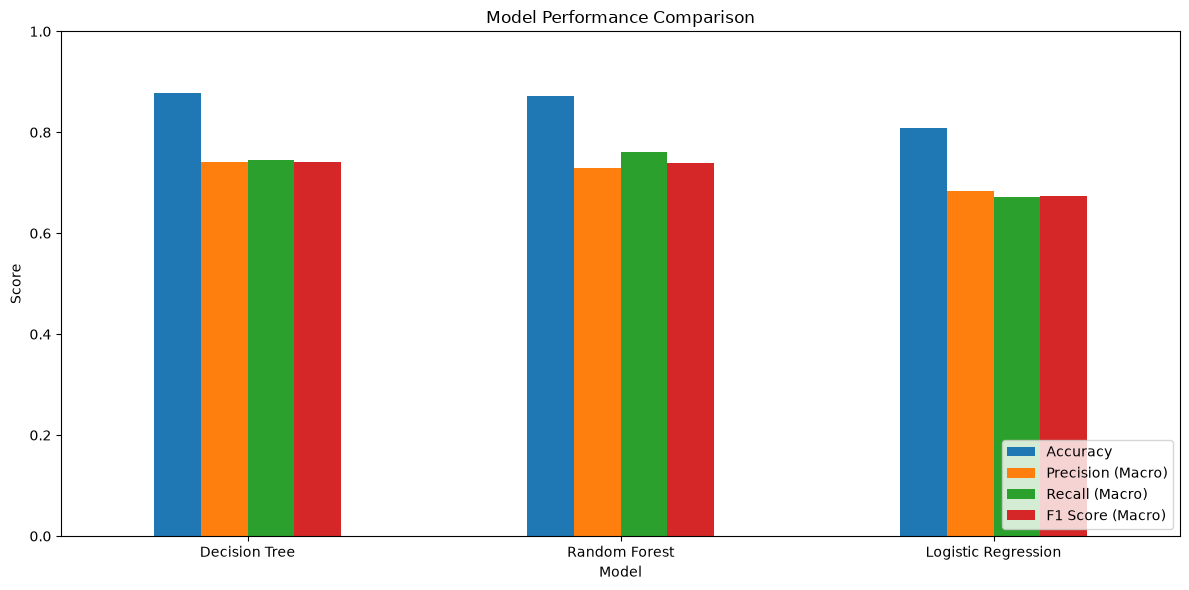

In [118]:
# Plot the model performance results as a bar chart
results_df.plot(
    kind = "bar",
    figsize = (12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)  # Keep the model names horizontal

plt.ylim(0, 1)  # Set the y axis range from 0 to 1

plt.legend(     # Display the legend in the lower right corner
    loc="lower right"
)

plt.tight_layout()
plt.show()

Confusion Matrix for Random Forest Model Predictions

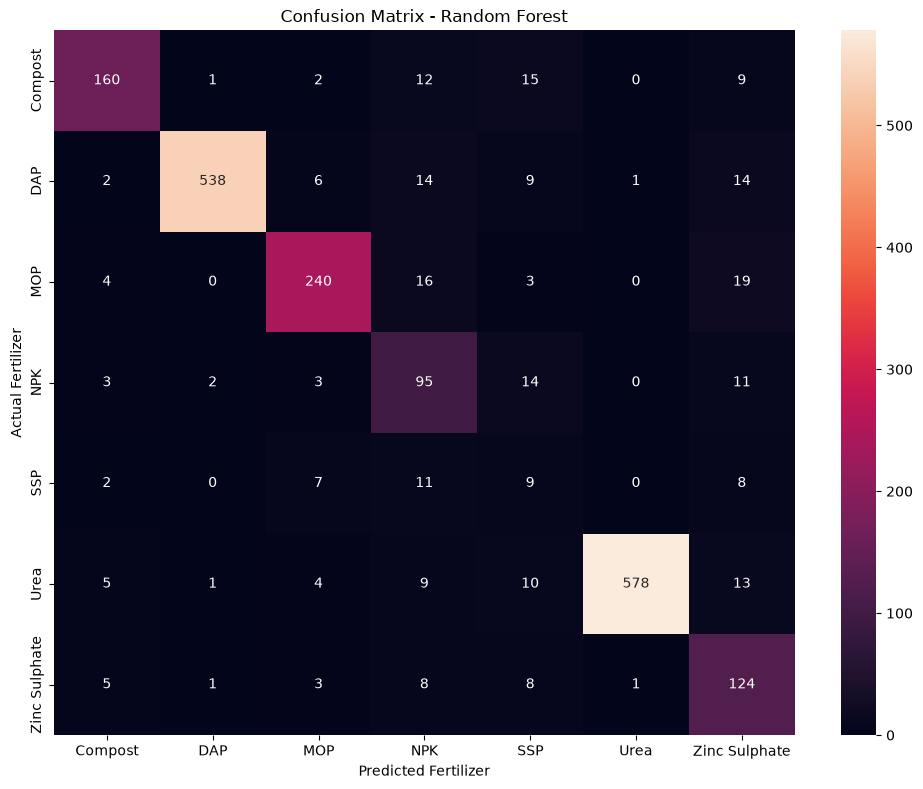

In [119]:
# Calculate the confusion matrix using the actual and predicted labels
cm = confusion_matrix(
    Y_test_encoded,
    random_forest_predictions
)

plt.figure(figsize=(10, 8))     # Create a figure for the confusion matrix

sns.heatmap(    # Display the confusion matrix as a heatmap
    cm,
    annot=True,     # Display the values inside each cell
    fmt="d",    # Format the values as integers
    xticklabels=label_encoder.classes_,     # Labels for predicted classes
    yticklabels=label_encoder.classes_  # Labels for actual classes
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")

plt.tight_layout()
plt.show()

Feature Importance

In [120]:
# Get the feature names after preprocessing and feature engineering
feature_names_fe = preprocessor_fe.get_feature_names_out()

# Create a DataFrame containing each feature and its importance score
feature_importance = pd.DataFrame({
    "Feature": feature_names_fe,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,num__Nitrogen_Level,0.114963
5,num__Phosphorus_Level,0.099890
0,num__Soil_pH,0.093032
13,num__N_to_P_Ratio,0.072319
6,num__Potassium_Level,0.070647
14,num__N_to_K_Ratio,0.061010
15,num__P_to_K_Ratio,0.060969
12,num__Total_NPK,0.047544
33,cat__Crop_Growth_Stage_Vegetative,0.044557
45,cat__Soil_pH_Category_Acidic,0.043501


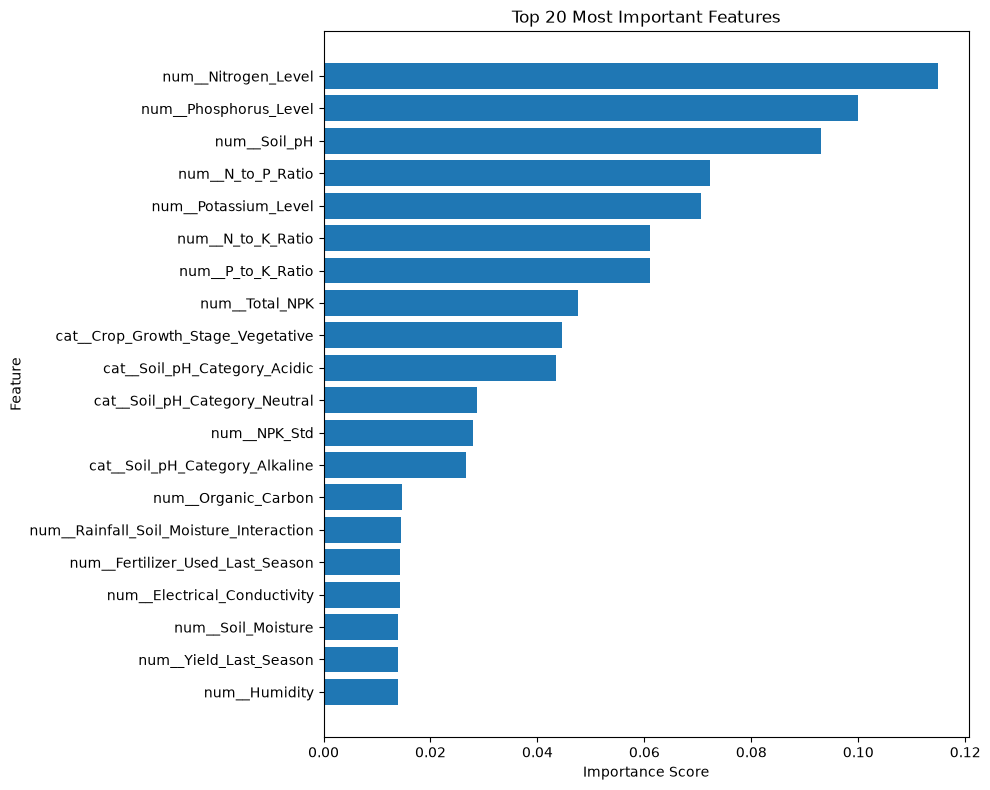

In [121]:
# Select the top 20 most important features
top_features = feature_importance.head(20)

# Create the figure and set its size
plt.figure(figsize=(10, 8))

# Create a horizontal bar chart
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

# Add labels to the x axis and y axis
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# chart title
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()   # Invert the y axis (the most important feature appears at the top)

plt.tight_layout()  # Adjust the layout to prevent labels from being cut off
plt.show()

XGBoost Model

In [122]:
xgb_model = XGBClassifier( 
    n_estimators = 300,        # Number of boosting trees
    learning_rate = 0.05,      # Step size used to update the model
    max_depth = 6,             # Maximum depth of each decision tree
    subsample = 0.8,           # Uses 80% of training samples for each tree
    colsample_bytree = 0.8,    # Uses 80% of features for each tree
    random_state = 42,         # Uses all available CPU cores
    n_jobs = -1,               # Uses all available CPU cores
    eval_metric = "mlogloss"   # Evaluation metric for multiclass classification
)

xgb_model, xgb_predictions = evaluate_model(
    xgb_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "XGBoost"
)

XGBoost
Accuracy: 0.8770
Precision (Macro): 0.7336
Recall (Macro): 0.7331
F1 Score (Macro): 0.7308


CatBoost Model

In [123]:
catboost_model = CatBoostClassifier(
    iterations = 500,     # Number of boosting iterations
    learning_rate = 0.05,     # Controls the step size during model training
    depth = 6,             # Maximum depth of each decision tree
    random_seed = 42,    # Ensures reproducible results
    verbose = 0        # Suppresses training output
)

catboost_model, catboost_predictions = evaluate_model(
    catboost_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "CatBoost"
)

CatBoost
Accuracy: 0.8700
Precision (Macro): 0.7154
Recall (Macro): 0.7253
F1 Score (Macro): 0.7189


Summary of Results

In [124]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="F1 Score (Macro)",
    ascending=False
)

results_df

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Decision Tree,0.8775,0.740510,0.744189,0.742039
Random Forest,0.8720,0.730194,0.760096,0.738605
XGBoost,0.8770,0.733557,0.733100,0.730838
CatBoost,0.8700,0.715436,0.725328,0.718858
Logistic Regression,0.8090,0.682947,0.671559,0.674546


Hyperparameter Tuning - Decision Tree

In [125]:
# Define the hyperparameter search space
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],     # Function used to measure the quality of a split
    "max_depth": [None, 5, 10, 15, 20, 30],  # Maximum depth of the decision tree
    "min_samples_split": [2, 5, 10, 15, 20],     # Minimum number of samples required to split a node
    "min_samples_leaf": [1, 2, 4, 6, 10],   # Minimum number of samples required in a leaf node
    "max_features": [None, "sqrt", "log2"]  # Number of features considered when looking for the best split
}

# Create the base Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state = 42,
    class_weight = "balanced"
)

# Set up RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator = dt_model,     # model that will be tuned
    param_distributions = dt_param_grid,  # Hyperparameters and values to randomly search
    n_iter = 30,  # Number of random parameter combinations to test
    scoring = "f1_macro", # Metric used to select the best model (Macro F1 gives equal importance to every class)
    cv = 5,     # 5-fold cross-validation
    verbose = 1,     # Displays the progress during training
    random_state = 42,  # Ensures the same random combinations are selected every time the code is run
    n_jobs = -1     # Uses all available CPU cores
)

# Perform hyperparameter tuning
dt_random_search.fit(
    X_train_fe_processed,   
    Y_train_encoded
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a func

Check Best Decision Tree Parameters and Results

In [126]:
print("Best Parameters:")
print(dt_random_search.best_params_) # Display the best hyperparameters found during RandomizedSearchCV

print("\nBest Cross-Validation Macro F1:")
print(dt_random_search.best_score_)  # Display the best Macro F1-score achieved during 5-fold cross-validation

# Get the Decision Tree model with the best hyperparameters
best_dt_model = dt_random_search.best_estimator_

# Use the tuned Decision Tree to make predictions on the test data
best_dt_predictions = best_dt_model.predict(
    X_test_fe_processed
)

accuracy = accuracy_score(      # Calculate the accuracy of the tuned model
    Y_test_encoded,
    best_dt_predictions
)

precision = precision_score(    # Calculate Macro Precision
    Y_test_encoded,
    best_dt_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(      # Calculate Macro Recall
    Y_test_encoded,
    best_dt_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(      # Calculate Macro F1 Score
    Y_test_encoded,
    best_dt_predictions,
    average="macro",
    zero_division=0
)

# Display the final performance of the tuned Decision Tree
print("\nTuned Decision Tree Results")
print("=" * 30)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

Best Parameters:
{'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'criterion': 'log_loss'}

Best Cross-Validation Macro F1:
0.7936939790649442

Tuned Decision Tree Results
Accuracy: 0.8645
Precision (Macro): 0.8011
Recall (Macro): 0.7966
F1 Score (Macro): 0.7657


Tune Random Forest Hyperparameters

In [127]:
# Define the hyperparameter search space
rf_param_grid = {
    "n_estimators": [200, 300, 500, 700],   # Number of decision trees in the Random Forest
    "max_depth": [None, 10, 20, 30, 40],     # Maximum depth of each decision tree
    "min_samples_split": [2, 5, 10],     # Minimum number of samples required to split a node
    "min_samples_leaf": [1, 2, 4],      # Minimum number of samples required in a leaf node
    "max_features": ["sqrt", "log2"],        # Number of features considered when finding the best split
    "class_weight": ["balanced", "balanced_subsample"]      # Methods for handling class imbalance
}

# Create the base Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Set up RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator = rf_model,    # The Random Forest model to be tuned
    param_distributions = rf_param_grid,    # Hyperparameters and values to randomly search
    n_iter = 25,    # Number of randomly selected parameter combinations
    scoring = "f1_macro",    # Macro F1 is used to select the best model
    cv = 5,      # Uses 5-fold cross-validation
    verbose = 1,        # Displays the training progress
    random_state = 42,    # Ensures the same random combinations are selected every time the code is run
    n_jobs = -1     # Uses all available CPU cores
)

# Perform hyperparameter tuning
rf_random_search.fit(
    X_train_fe_processed,
    Y_train_encoded
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be se

Best Random Forest Parameters and Results

In [128]:
print("Best Parameters:")
print(rf_random_search.best_params_)    # Display the best hyperparameters found during RandomizedSearchCV

print("\nBest Cross-Validation Macro F1:")
print(rf_random_search.best_score_)     # Display the best Macro F1-score obtained during 5-fold cross-validation

best_rf_model = rf_random_search.best_estimator_    # Retrieve the Random Forest model with the best hyperparameters

# Use the tuned Random Forest to make predictions on test data 
best_rf_predictions = best_rf_model.predict(
    X_test_fe_processed
)

accuracy = accuracy_score(      # Calculate the accuracy of the tuned Random Forest
    Y_test_encoded,
    best_rf_predictions
)

precision = precision_score(    # Calculate Macro Precision
    Y_test_encoded,
    best_rf_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(      # Calculate Macro Recall
    Y_test_encoded,
    best_rf_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(      # Calculate Macro F1 Score
    Y_test_encoded,
    best_rf_predictions,
    average="macro",
    zero_division=0
)

# Display the final results
print("\nTuned Random Forest Results")
print("=" * 30)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}

Best Cross-Validation Macro F1:
0.7978171025047295

Tuned Random Forest Results
Accuracy: 0.8650
Precision (Macro): 0.8322
Recall (Macro): 0.8022
F1 Score (Macro): 0.7771


Tune Catboost Hyperparameters

In [129]:
# Define the hyperparameter search space 
cat_param_grid = {
    "iterations": [300, 500, 700, 1000],    # Number of boosting iterations
    "depth": [4, 5, 6, 7, 8],       # Maximum depth of each decision tree
    "learning_rate": [0.01, 0.03, 0.05, 0.1],    # Controls how quickly the model learns from each iteration
    "l2_leaf_reg": [1, 3, 5, 7, 10]     # L2 regularization to reduce overfitting
}

# Create the CatBoost classifier 
cat_model = CatBoostClassifier(
    random_seed = 42,
    verbose = 0
)

# Set up RandomizedSearchCV to find the best combination of parameters
cat_random_search = RandomizedSearchCV(
    estimator = cat_model,    # CatBoost model to be tuned
    param_distributions = cat_param_grid,     # Hyperparameters and values to randomly search
    n_iter = 20,  # Number of randomly selected combinations
    scoring = "f1_macro",     # Use macro F1-score for model evaluation
    cv = 5,       # Apply 5-fold cross-validation
    verbose = 1,      # Displays the training progress
    random_state = 42,    # Ensures the same random combinations are selected every time the code is run
    n_jobs = -1   # Uses all CPU cores
)

# Perform hyperparameter tuning
cat_random_search.fit(
    X_train_fe_processed,
    Y_train_encoded
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 5, ...], 'iterations': [300, 500, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.03, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the se

Best CatBoost Parameters and Results

In [130]:
print("Best Parameters:")
print(cat_random_search.best_params_)  # Display the best hyperparameters found during RandomizedSearchCV

print("\nBest Cross-Validation Macro F1:")
print(cat_random_search.best_score_)  # Display the best Macro F1-score achieved during 5-fold cross-validation

best_cat_model = cat_random_search.best_estimator_  # Retrieve the CatBoost model trained with the best hyperparameters

best_cat_predictions = best_cat_model.predict(   # Generate predictions on the preprocessed test dataset
    X_test_fe_processed
)

accuracy = accuracy_score(      # Calculate the overall accuracy
    Y_test_encoded,
    best_cat_predictions
)

precision = precision_score(    # Calculate Macro Precision
    Y_test_encoded,
    best_cat_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(      # Calculate Macro Recall to evaluate how well each class is identified
    Y_test_encoded,
    best_cat_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(      # Calculate the Macro F1-score
    Y_test_encoded,
    best_cat_predictions,
    average="macro",
    zero_division=0
)

# Display the final results 
print("\nTuned CatBoost Results")
print("=" * 30)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

Best Parameters:
{'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 6}

Best Cross-Validation Macro F1:
0.7550193408066678

Tuned CatBoost Results
Accuracy: 0.8720
Precision (Macro): 0.7217
Recall (Macro): 0.7320
F1 Score (Macro): 0.7257


Selection of the final model

In [131]:
# Select the tuned Random Forest model as the final model
final_model = best_rf_model

# Generate predictions on the preprocessed test dataset
final_predictions = final_model.predict(
    X_test_fe_processed
)

Classification Report

In [132]:
print(
    classification_report(
        Y_test_encoded,
        final_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

               precision    recall  f1-score   support

      Compost       1.00      0.77      0.87       199
          DAP       1.00      0.92      0.96       584
          MOP       1.00      0.83      0.91       282
          NPK       0.92      0.67      0.78       128
          SSP       0.10      0.73      0.18        37
         Urea       1.00      0.93      0.96       620
Zinc Sulphate       0.80      0.76      0.78       150

     accuracy                           0.86      2000
    macro avg       0.83      0.80      0.78      2000
 weighted avg       0.96      0.86      0.90      2000



Confusion Matrix for the Final Random Forest Model

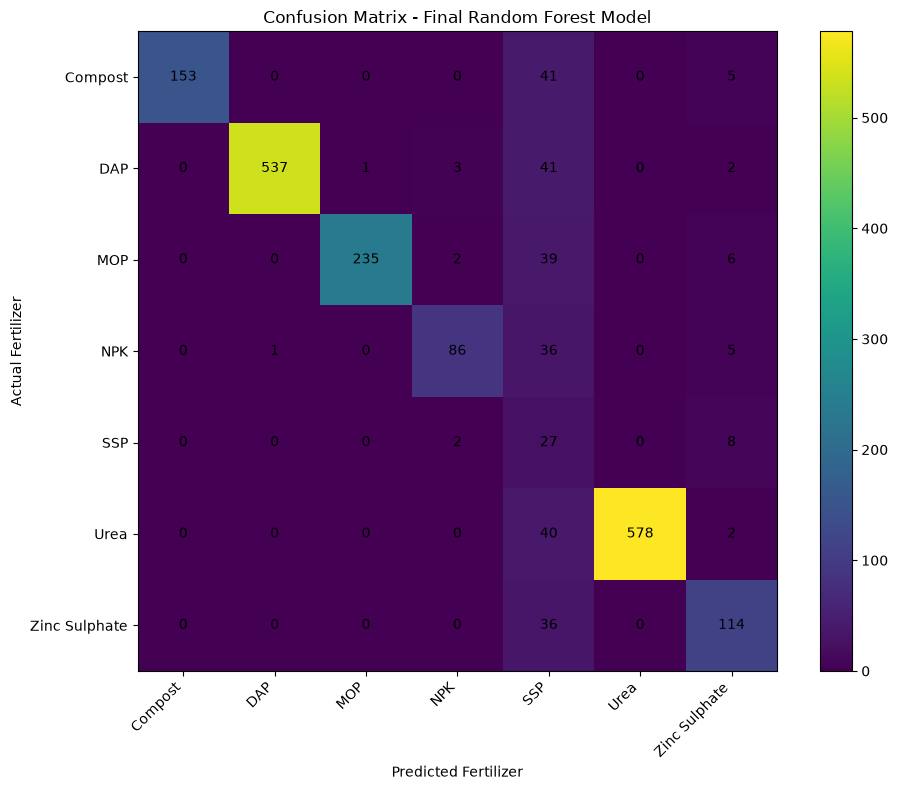

In [133]:
cm = confusion_matrix(
    Y_test_encoded,
    final_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation = 45,
    ha = "right"
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")

plt.title("Confusion Matrix - Final Random Forest Model")

# Add values to the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Feature Importance Analysis

In [134]:
# Get the feature names after preprocessing and feature engineering
feature_names_fe = preprocessor_fe.get_feature_names_out()

# Create a DataFrame containing each feature and its importance score
feature_importance = pd.DataFrame({
    "Feature": feature_names_fe,
    "Importance": final_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the 20 most important features
feature_importance.head(20)

,Feature,Importance
4,num__Nitrogen_Level,0.149014
5,num__Phosphorus_Level,0.119685
0,num__Soil_pH,0.100381
13,num__N_to_P_Ratio,0.088277
6,num__Potassium_Level,0.082703
15,num__P_to_K_Ratio,0.071628
14,num__N_to_K_Ratio,0.065698
45,cat__Soil_pH_Category_Acidic,0.060546
33,cat__Crop_Growth_Stage_Vegetative,0.052290
12,num__Total_NPK,0.047947


Plot for top 20 features 

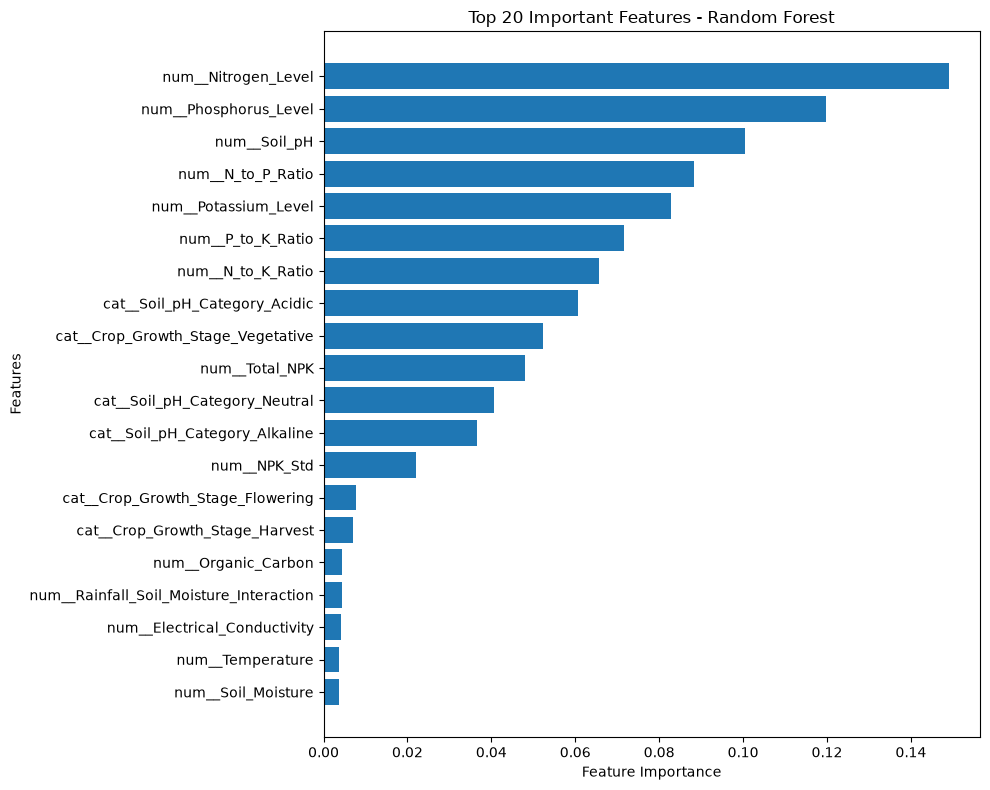

In [135]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.title("Top 20 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Prediction Confidence Analysis

In [136]:
# Get the probability of each class for every test sample
probabilities = final_model.predict_proba(X_test_fe_processed)

# Get the highest predicted probability for each sample
confidence_scores = np.max(
    probabilities,
    axis = 1
)

# Create a DataFrame showing actual, predicted, and confidence
sample_results = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(
        Y_test_encoded[:10]
    ),
    "Predicted": label_encoder.inverse_transform(final_predictions[:10]),
    "Confidence": confidence_scores[:10]
})

# Convert confidence scores from decimals to percentages
sample_results["Confidence (%)"] = (sample_results["Confidence"] * 100).round(2)

sample_results

,Actual,Predicted,Confidence,Confidence (%)
0,Compost,Compost,0.921035,92.10
1,Urea,Urea,0.752981,75.30
2,SSP,SSP,0.440744,44.07
3,MOP,MOP,0.898287,89.83
4,DAP,SSP,0.466996,46.70
5,DAP,DAP,0.915033,91.50
6,Urea,Urea,0.836774,83.68
7,Zinc Sulphate,Zinc Sulphate,0.804719,80.47
8,MOP,MOP,0.830696,83.07
9,MOP,MOP,0.874213,87.42


SHAP Feature Importance Analysis

In [137]:
# Initialize SHAP TreeExplainer for the final model
explainer = shap.TreeExplainer(final_model)

# Retrieve feature names after preprocessing
feature_names = preprocessor_fe.get_feature_names_out()

# Display the number of processed features
print("Number of features:", len(feature_names))

Number of features: 48


Preparing Test Data for SHAP Analysis

In [138]:
# Convert the preprocessed test data into a DataFrame
X_test_shap = pd.DataFrame(
    X_test_fe_processed,
    columns=feature_names
)

# Display the first five rows of the processed test dataset
X_test_shap.head()

,num__Soil_pH,num__Soil_Moisture,num__Organic_Carbon,num__Electrical_Conductivity,num__Nitrogen_Level,num__Phosphorus_Level,num__Potassium_Level,num__Temperature,num__Humidity,num__Rainfall,...,cat__Previous_Crop_Cotton,cat__Previous_Crop_Maize,cat__Previous_Crop_Potato,cat__Previous_Crop_Rice,cat__Previous_Crop_Sugarcane,cat__Previous_Crop_Tomato,cat__Previous_Crop_Wheat,cat__Soil_pH_Category_Acidic,cat__Soil_pH_Category_Alkaline,cat__Soil_pH_Category_Neutral
0,-0.996090,-0.113720,0.559346,-0.004356,0.503325,0.512612,0.315878,1.112904,1.015785,1.157759,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.584654,0.024316,1.256475,-1.129724,-0.838344,-1.635939,1.165087,-0.294937,0.118931,-0.090522,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.023187,-1.598124,-0.352285,-0.620347,-0.192356,0.985293,1.070731,0.526594,1.630148,0.023229,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.506912,0.400273,-0.674037,0.872246,1.348079,0.770438,-0.973662,0.554403,1.691010,-1.302602,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.184123,1.532998,0.452095,-0.738807,0.478479,0.899351,1.353801,-0.973945,-1.379080,-0.154883,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


Calculating SHAP Values

In [139]:
# Select a sample of up to 500 test observations for SHAP analysis
X_shap_sample = X_test_shap.sample(
    n = min(500, len(X_test_shap)),
    random_state = 42
)

# Calculate SHAP values for the selected test samples
# These values indicate how much each feature contributes to the model's predictions
shap_values = explainer.shap_values(
    X_shap_sample
)

# Display the data type of the SHAP values
print(type(shap_values))

# Display the shape of the SHAP values to verify the number of samples and features.
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(500, 48, 7)


In [140]:
# Calculate mean absolute SHAP values
global_shap_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 2)
)

# Create a DataFrame containing feature names and their corresponding mean absolute SHAP values
shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP Value|": global_shap_importance
})

# Sort by importance
shap_importance_df = shap_importance_df.sort_values(
    by = "Mean |SHAP Value|",
    ascending = False
)

# Display top 20 features
shap_importance_df.head(20)

,Feature,Mean |SHAP Value|
5,num__Phosphorus_Level,0.055621
4,num__Nitrogen_Level,0.052869
6,num__Potassium_Level,0.030508
13,num__N_to_P_Ratio,0.022187
0,num__Soil_pH,0.021019
15,num__P_to_K_Ratio,0.017847
45,cat__Soil_pH_Category_Acidic,0.017368
14,num__N_to_K_Ratio,0.016160
47,cat__Soil_pH_Category_Neutral,0.015613
12,num__Total_NPK,0.015612


Plot for the top 20 features influencing fertilizer recommendations

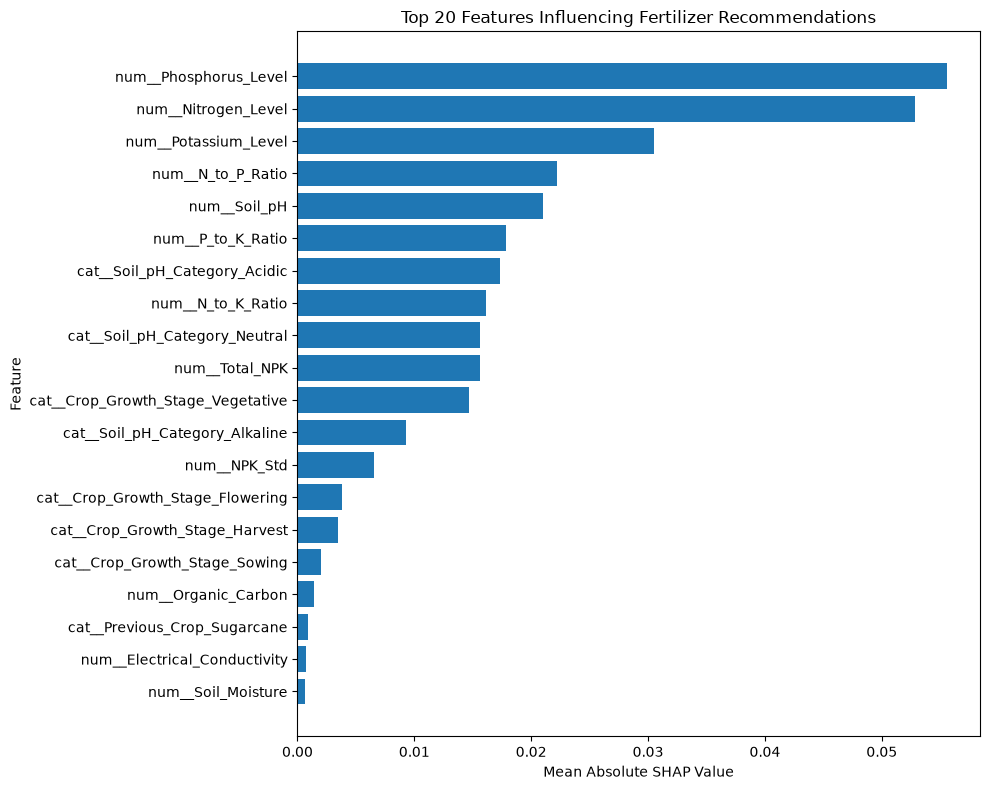

In [141]:
top_shap_features = shap_importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean |SHAP Value|"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.title("Top 20 Features Influencing Fertilizer Recommendations")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Mapping Encoded Classes to Fertilizer Names

In [142]:
print(label_encoder.classes_)       # Display all fertilizer classes stored in the label encoder

class_names = label_encoder.classes_    # Store the fertilizer class names 

for i, fertilizer in enumerate(class_names):
    print(i, "->", fertilizer)

['Compost' 'DAP' 'MOP' 'NPK' 'SSP' 'Urea' 'Zinc Sulphate']
0 -> Compost
1 -> DAP
2 -> MOP
3 -> NPK
4 -> SSP
5 -> Urea
6 -> Zinc Sulphate


SHAP Summary Plot for Urea Recommendation

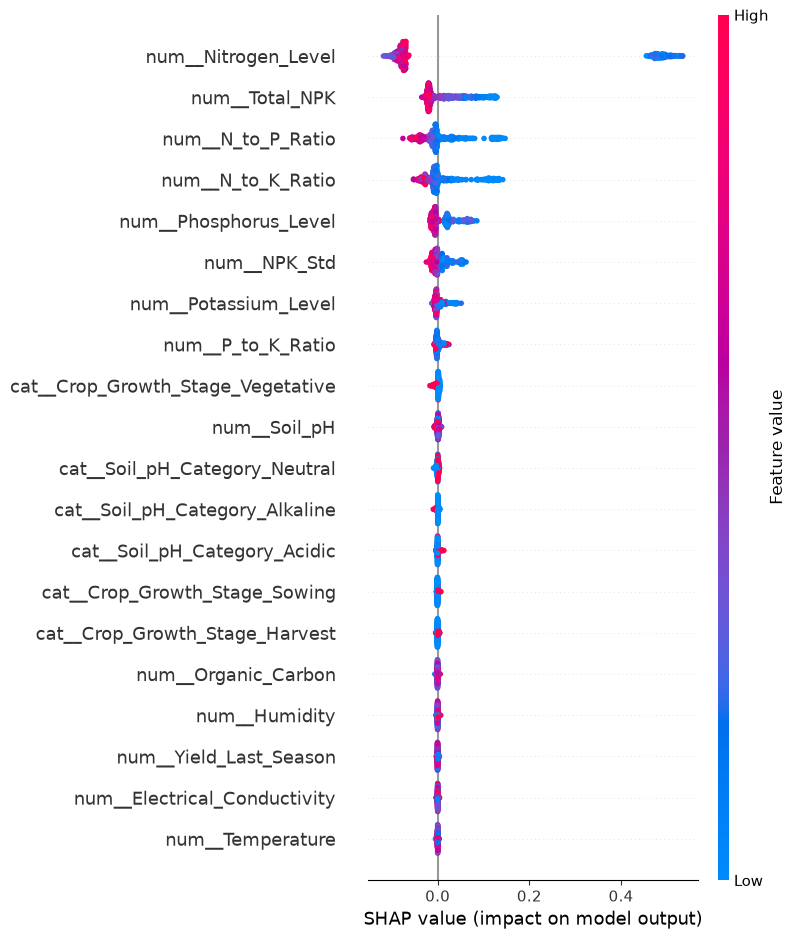

In [143]:
urea_index = list(class_names).index("Urea")

shap.summary_plot(
    shap_values[:, :, urea_index],
    X_shap_sample,
    feature_names = feature_names,
    show = True
)

SHAP Summary Plot for DAP Recommendation

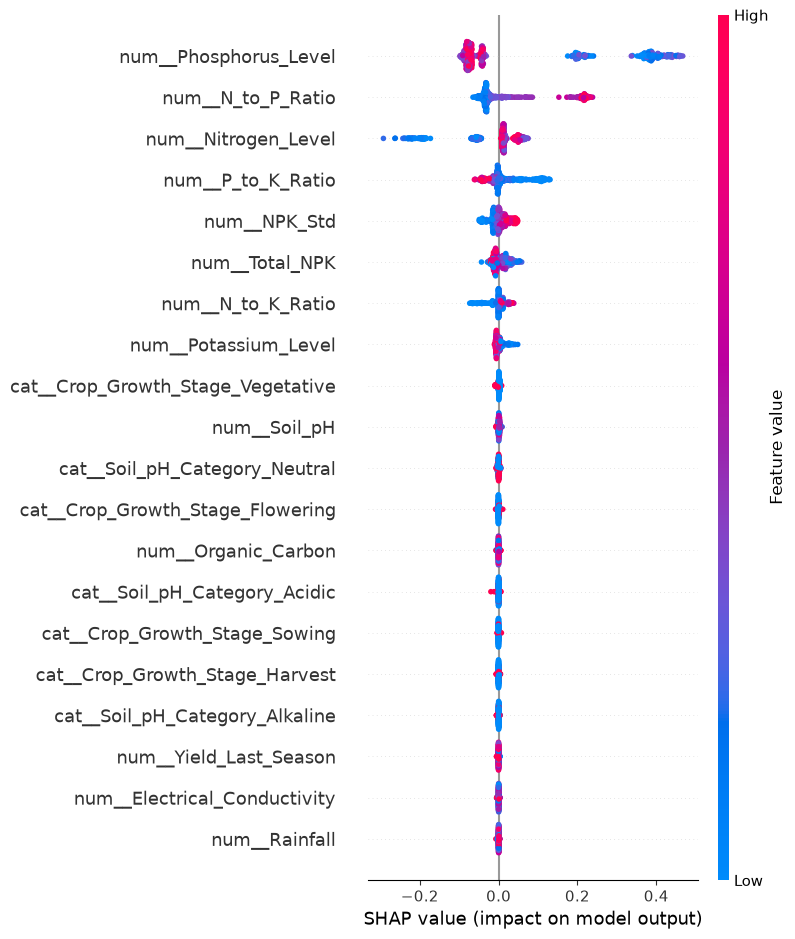

In [144]:
dap_index = list(class_names).index("DAP")

shap.summary_plot(
    shap_values[:, :, dap_index],
    X_shap_sample,
    feature_names=feature_names
)

SHAP Summary Plot for SSP Recommendation

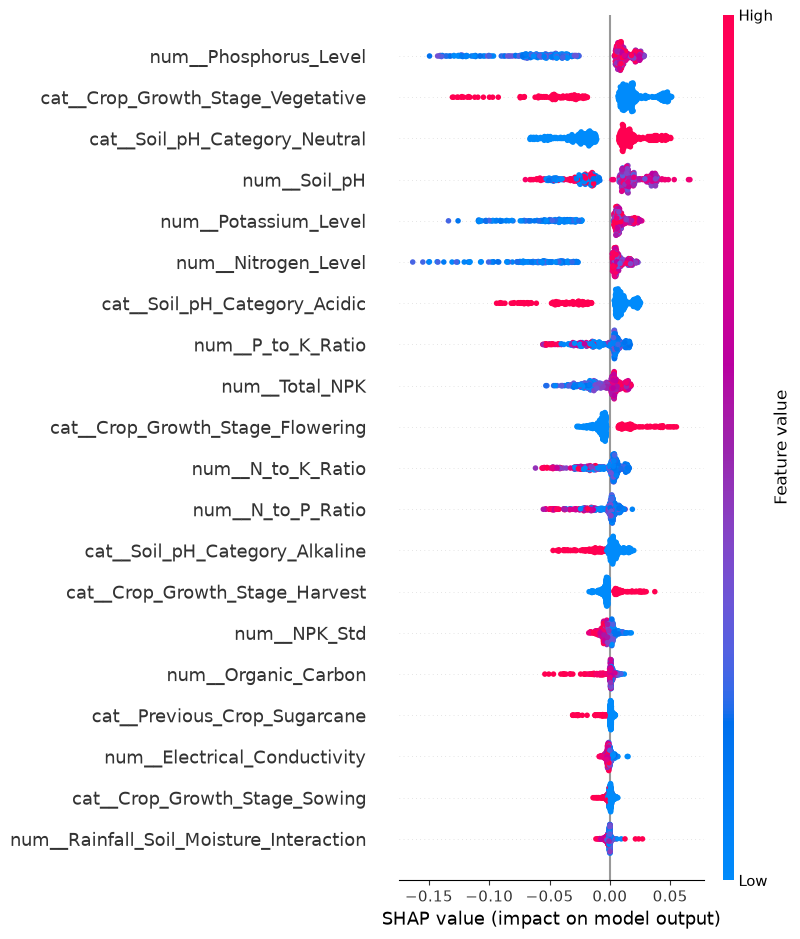

In [145]:
ssp_index = list(class_names).index("SSP")

shap.summary_plot(
    shap_values[:, :, ssp_index],
    X_shap_sample,
    feature_names=feature_names
)

Testing the Model with an Individual Fertilizer Recommendation and Confidence

In [146]:
# Select the first sample
sample_index = 0

# Keep the DataFrame for displaying the feature values
sample_data = X_shap_sample.iloc[[sample_index]]

# Convert the sample to a NumPy array 
sample_array = sample_data.to_numpy()

# Generate the predicted fertilizer class
sample_prediction = final_model.predict(sample_array)[0]

# Convert the encoded class back to the fertilizer name
predicted_fertilizer = label_encoder.inverse_transform([sample_prediction])[0]

# Calculate prediction probabilities
prediction_probability = final_model.predict_proba(sample_array)

# Get the highest predicted probability as confidence
confidence = np.max(prediction_probability)

print("Recommended Fertilizer:", predicted_fertilizer)
print("Prediction Confidence:", round(confidence * 100, 2), "%")

Recommended Fertilizer: DAP
Prediction Confidence: 90.41 %


SHAP Waterfall Plot for Individual Prediction

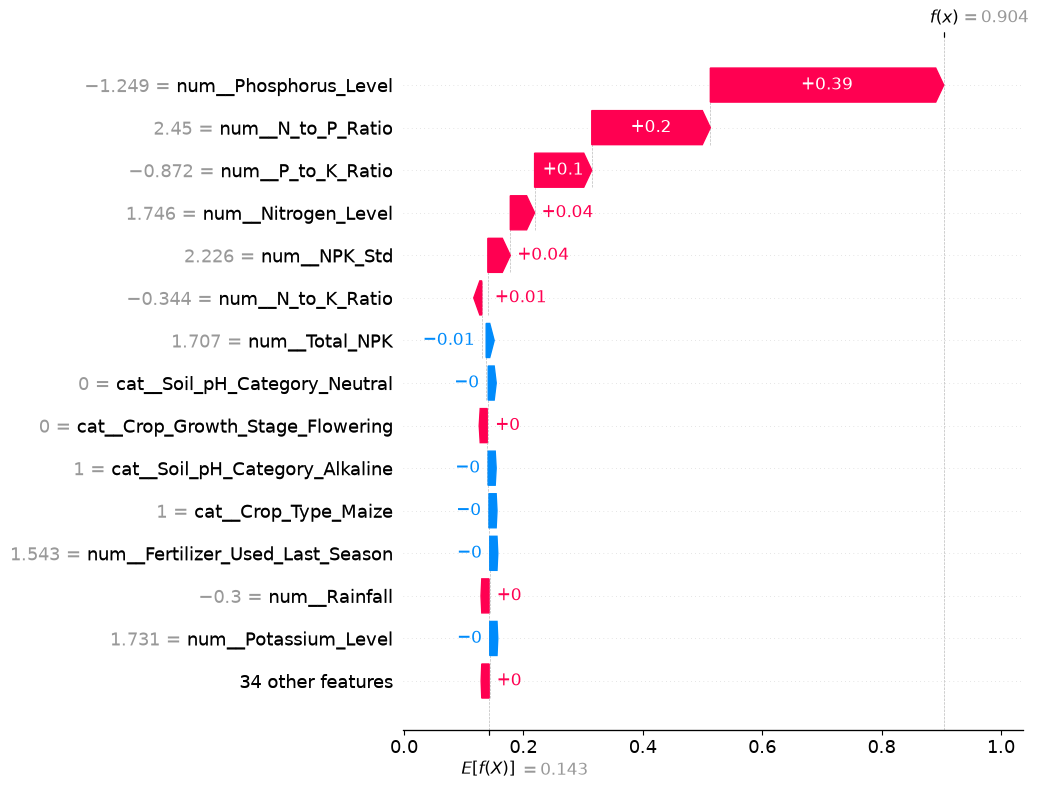

In [147]:
# Get the encoded class index of the fertilizer predicted 
class_index = sample_prediction

# Extract the SHAP values for the selected sample and its predicted fertilizer class
sample_shap_values = shap_values[sample_index, :, class_index]

# Create a SHAP Explanation object 
sample_explanation = shap.Explanation(
    values = sample_shap_values,
    base_values = explainer.expected_value[class_index],
    data = sample_data.iloc[0].values,
    feature_names = feature_names
)

# Generate a waterfall plot showing the 15 most influential features contributing to this prediction
shap.plots.waterfall(
    sample_explanation,
    max_display=15
)

In [148]:
# Create a DataFrame containing each feature and its SHAP contribution
shap_contributions = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": sample_shap_values
})

# Calculate the absolute SHAP value (measure the magnitude of each feature's contribution regardless of its direction)
shap_contributions["Absolute SHAP"] = (shap_contributions["SHAP Value"].abs())

# Sort features from the most influential to the least influential based on the magnitude of their SHAP contributions
shap_contributions = shap_contributions.sort_values(
    by="Absolute SHAP",
    ascending=False
)

# Display the top 10 features with the largest contributions
shap_contributions.head(10)

,Feature,SHAP Value,Absolute SHAP
5,num__Phosphorus_Level,0.390986,0.390986
13,num__N_to_P_Ratio,0.198617,0.198617
15,num__P_to_K_Ratio,0.095748,0.095748
4,num__Nitrogen_Level,0.040697,0.040697
16,num__NPK_Std,0.037645,0.037645
14,num__N_to_K_Ratio,0.010209,0.010209
12,num__Total_NPK,-0.007440,0.007440
47,cat__Soil_pH_Category_Neutral,-0.003420,0.003420
30,cat__Crop_Growth_Stage_Flowering,0.001678,0.001678
46,cat__Soil_pH_Category_Alkaline,-0.001574,0.001574


Confusion Matrix

In [149]:
# Generate the confusion matrix by comparing the actual test labels with the predictions
cm = confusion_matrix(
    Y_test_encoded,
    final_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"

cm_df

Predicted,Compost,DAP,MOP,NPK,SSP,Urea,Zinc Sulphate
Actual,,,,,,,
Compost,153,0,0,0,41,0,5
DAP,0,537,1,3,41,0,2
MOP,0,0,235,2,39,0,6
NPK,0,1,0,86,36,0,5
SSP,0,0,0,2,27,0,8
Urea,0,0,0,0,40,578,2
Zinc Sulphate,0,0,0,0,36,0,114


Saving the final model and preprocessing components

In [150]:
# Create the models folder 
os.makedirs("models", exist_ok=True)

# Save the trained final Random Forest model
joblib.dump(
    final_model,
    "models/fertilizer_random_forest_model.pkl"
)

# Save the feature engineering and preprocessing pipeline
# (This ensures new input data is transformed in the same way as the data used during model training)
joblib.dump(
    preprocessor_fe,
    "models/fertilizer_preprocessor.pkl"
)

# Save the label encoder 
joblib.dump(
    label_encoder,
    "models/fertilizer_label_encoder.pkl"
)

# Save the names of the features after preprocessing and feature engineering
joblib.dump(
    preprocessor_fe.get_feature_names_out(),
    "models/fertilizer_feature_names.pkl"
)

# Save the original input column names used before preprocessing
# (These columns are required when preparing new user inputs for prediction)
joblib.dump(
    X_train.columns.tolist(),
    "models/fertilizer_input_columns.pkl"
)

print("All model artifacts saved successfully in the 'models' folder.")

All model artifacts saved successfully in the 'models' folder.
